<div style="display: flex; align-items: center; justify-content: center; flex-wrap: wrap;">
    <div style="flex: 1; max-width: 400px; display: flex; justify-content: center;">
        <img alt="NOVA IMS logo" src="https://magic.novaims.unl.pt/media/1tdf2arr/ims25_horizontal__positivo_rgb.svg" style="max-width: 70%; height: auto; margin-top: 50px; margin-bottom: 50px;margin-left: 6rem;">
    </div>
    <div style="flex: 2; text-align: center; margin-top: 20px;margin-left: 6rem;">
        <div style="font-size: 28px; font-weight: bold; line-height: 1.2;">
            <span style="color: #FFCD41;">Thesis Project |</span> <span style="color: #F58228;">LISBOA: Lisbon Itinerary System Based On AI</span>
        </div>
        <div style="font-size: 17px; font-weight: bold; margin-top: 10px;">
            2025 / 2026
        </div>
        <div style="font-size: 17px; font-weight: bold;">
            Master in Data Science and Advanced Analytics
        </div>
        <div style="margin-top: 20px;">
            <div>André Filipe Gomes Silvestre, 20240502</div>
            <div style="margin-top: 6px; font-size: 14px;"><b>Supervisors:</b> Prof. Dr. Bruno Jardim; Prof. Dr. Miguel de Castro Neto</div>
        </div>
    </div>
</div>

<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: linear-gradient(to right, #F58228, #FFCD41);
            padding: 15px; color: white; border-radius: 300px; text-align: center;">
    <center><h1 style="margin-left: 100px;margin-top: 10px; margin-bottom: 4px; color: white;
                       font-size: 32px; font-family: 'Avenir Next LT Pro', sans-serif;"><b>VisitLisboa & Lisboa Aberta Data Understanding</b></h1></center>
</div>

<br><br>

## **Notebook overview**

This notebook inspects the local VisitLisboa and municipal open-data snapshots used by the LISBOA project, updated on **2026-05-18**. It combines light cleaning, exploratory analysis, endpoint validation, and descriptive visualisations to understand source coverage, category balance, and dataset usefulness before these resources are promoted into the runtime pipeline.

The JSON counts and category frequencies shown here depend on the scraping snapshot available in `data_collection/webscraping/` at execution time. When the automated sync jobs refresh the source files, exact counts can change even if the notebook code stays correct.

The GeoJSON validation cell separates three states: valid GeoJSON, upstream-unavailable URLs that are explicitly annotated in `lisbon_datasets_clean.json`, and unexpected failures that require follow-up.

<br><br>


In [1]:
# Install the required packages
# !pip install json pandas matplotlib seaborn tqdm requests

In [2]:
# Import necessary libraries
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

%matplotlib inline

In [3]:
# Settings to customize plots
sns.set_theme(context='paper', style="white", font= 'Borna', rc={"figure.figsize":(48, 32)}, font_scale=1.5)

# Define a color palette based on the project colors (Orange/Yellow tones)
# #ff4011 (Red), #F58228 (Orange), #f6da00 (Yellow)
custom_palette = ['#ff4011', '#F58228', '#f6da00']
sns.set_palette(custom_palette)


In [4]:
from pathlib import Path

def resolve_project_root() -> Path:
    """Resolve the repository root when the notebook is opened from different working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "config.py").exists() and (candidate / "data_collection" / "webscraping").exists():
            return candidate
    return Path.cwd()


PROJECT_ROOT = resolve_project_root()
WEBSCRAPING_DIR = PROJECT_ROOT / "data_collection" / "webscraping"


def load_local_json(file_name: str):
    with (WEBSCRAPING_DIR / file_name).open("r", encoding="utf-8") as file_handle:
        return json.load(file_handle)


events_data = load_local_json("events.json")
places_data = load_local_json("places.json")
lisbon_datasets_original = load_local_json("lisbon_datasets.json")
lisbon_datasets_clean = load_local_json("lisbon_datasets_clean.json")

print(f"Loaded local snapshot files from: {WEBSCRAPING_DIR}")

Loaded local snapshot files from: C:\Users\andre\OneDrive - NOVAIMS\[MDSAA-DS]_Thesis\LISBOA_MultiAgentSystem\data_collection\webscraping


## **Dados Abertos Lisboa Analysis**

This section analyses two local JSON snapshots exported from the municipal/open-data scraping flow:

- `lisbon_datasets.json`: **310 records** discovered from the broader Lisboa/dados.gov.pt search flow.
- `lisbon_datasets_clean.json`: **168 GeoJSON-oriented records** used by the Lisboa Aberta tools.

Counts and URL availability can change after sync jobs or when upstream endpoints are removed, rate-limited, redirected, or return non-200 responses.

Validation status on **2026-05-18**:

- 5 stale `dados.gov.pt` resource redirects were replaced with directly queryable ArcGIS GeoJSON endpoints.
- 7 `MapaConhecimento` resources remain annotated in `lisbon_datasets_clean.json` through `stable_url_comment` because the official portals still point to removed ArcGIS layers and no exact working GeoJSON replacement was verified.
- The notebook treats annotated upstream-unavailable resources as documented limitations, not as unexpected notebook failures.
- The expected validation result for this snapshot is **161 valid GeoJSON URLs**, **7 annotated upstream-unavailable resources**, and **0 unexpected failures**.

### **Lisboa Aberta Snapshot Fields**

| Field | Present in | Description |
|-------|------------|-------------|
| `title` | original + clean | Dataset/resource title |
| `description` | original + clean | Dataset description from the portal |
| `file_formats` | original + clean | File formats advertised by the portal |
| `last_updated` | original + clean | Upstream update timestamp where available |
| `stable_url` | original + clean | Stable resource URL or direct working replacement |
| `url_portal` | original + clean | Source portal dataset page |
| `stable_url_comment` | clean only, when needed | Explanation for intentionally retained unavailable resources |

### **Original Dataset**

`lisbon_datasets.json` contains the broader scraped source catalogue before GeoJSON filtering and URL repair. Current snapshot size: **310 records**.

In [5]:
# Create a DataFrame for Lisbon Open Data (Original)
df_lisbon = pd.DataFrame(lisbon_datasets_original)

# Display the first few rows
df_lisbon.head()

,title,url_portal,stable_url,description,file_formats,last_updated
0,Atlas Digital (Atlas Digital)Atlas Digital,https://dados.gov.pt/pt/datasets/atlas-digital/,https://dados.gov.pt/pt/datasets/r/28d9ca5b-ae...,O Atlas Digital da Área Metropolitana de Lisbo...,"html, pdf",2025-08-07T09:01:32.224000
1,Plano Metropolitano de Adaptação às Alterações...,https://dados.gov.pt/pt/datasets/plano-metropo...,https://dados.gov.pt/pt/datasets/r/4c7ea8af-f4...,O Plano Metropolitano de Adaptação às Alteraçõ...,"pdf, wms",2025-08-07T09:02:54.011000
2,Rede de monitorização e de alerta meteorológic...,https://dados.gov.pt/pt/datasets/rede-de-monit...,https://dados.gov.pt/pt/datasets/r/28365431-8e...,O projeto CLIMA.AML tem como objetivo a criaçã...,"html, xml",2025-07-31T10:00:05.407000
3,Pontos de Interesse Climate Walks,https://dados.gov.pt/pt/datasets/pontos-de-int...,https://dados.gov.pt/pt/datasets/r/c4f494b7-d8...,"Indicação do arvoredo, elementos de água, corr...",geojson,2025-06-06T00:00:00
4,Percursos Climate Walks,https://dados.gov.pt/pt/datasets/percursos-cli...,https://dados.gov.pt/pt/datasets/r/06ee59fa-7d...,"Indicação do arvoredo, elementos de água, corr...",geojson,2025-06-06T00:00:00


In [6]:
# Basic information about the dataset
print(f"\033[1mTotal number of datasets:\033[0m {len(df_lisbon)}")
print("\n\033[1mData Types:\033[0m")
pd.DataFrame(df_lisbon.dtypes, columns=['Data Type'])

Total number of datasets: 310

Data Types:


,Data Type
title,object
url_portal,object
stable_url,object
description,object
file_formats,object
last_updated,object


In [7]:
print("\n\033[1mMissing Values:\033[0m")
pd.DataFrame(df_lisbon.isnull().sum(), columns=['Missing Values'])


Missing Values:


,Missing Values
title,0
url_portal,0
stable_url,0
description,0
file_formats,0
last_updated,0


<Figure size 3600x1800 with 1 Axes>
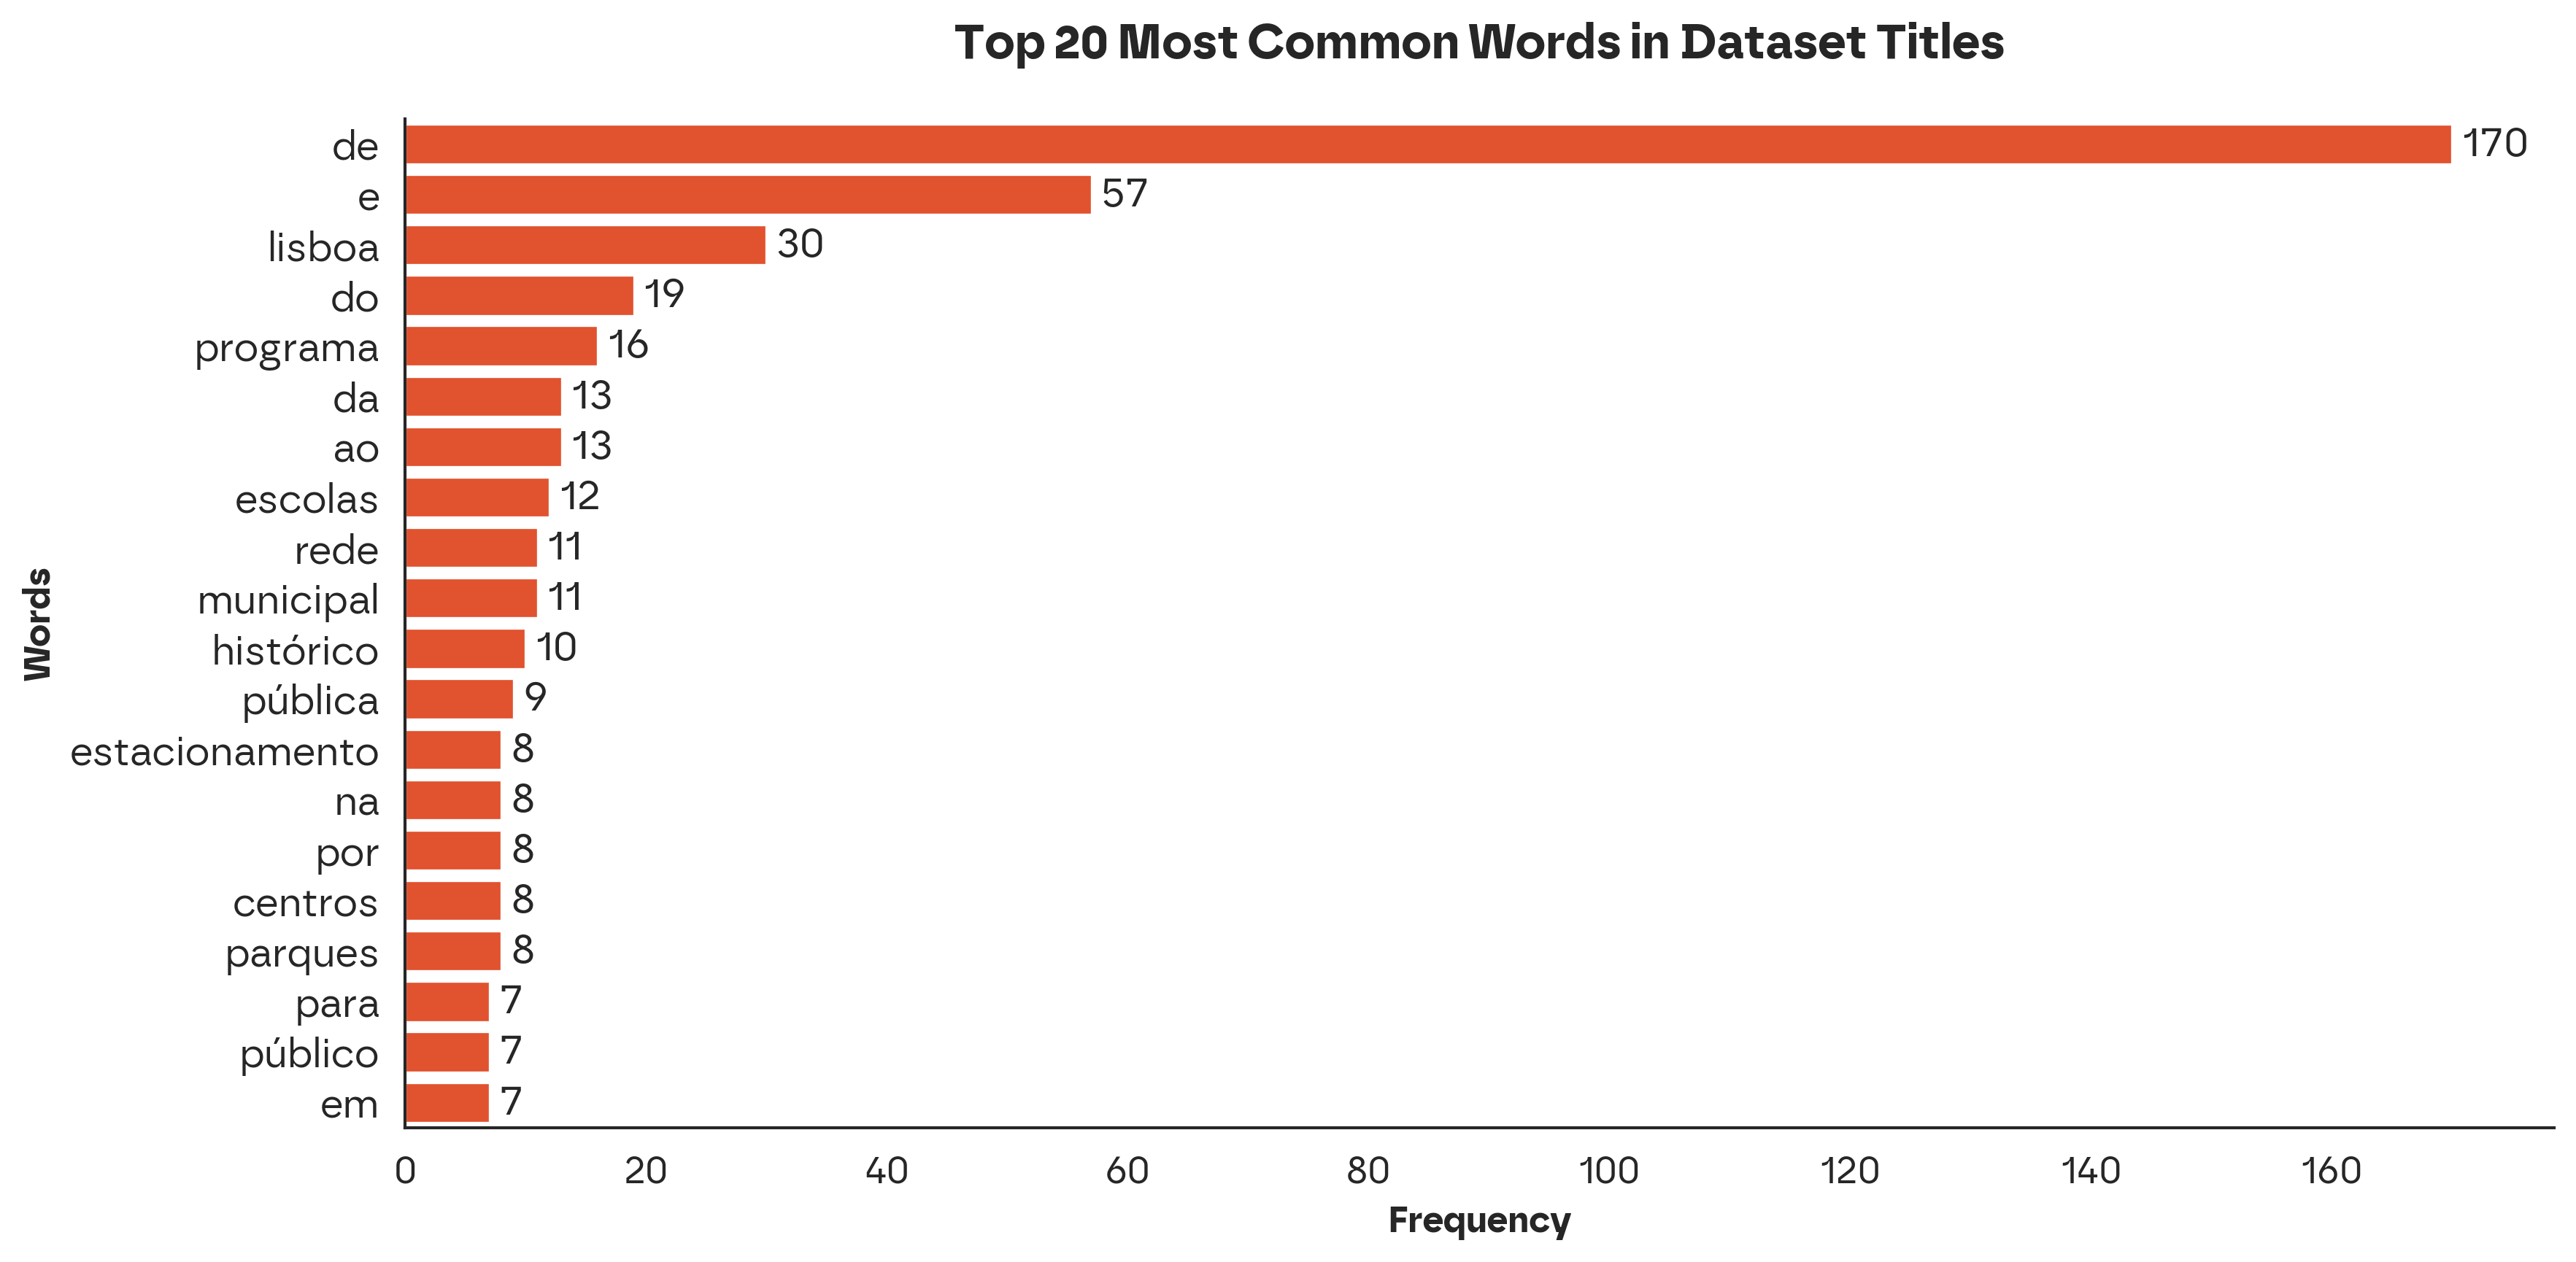

In [8]:
# Function to clean and tokenize text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

# Analyze titles
all_titles = " ".join(df_lisbon['title'].astype(str))
title_words = clean_text(all_titles)
title_word_counts = Counter(title_words)

# Prepare data for plotting
top_words_df = pd.DataFrame(title_word_counts.most_common(20), columns=['Word', 'Count'])

# Plot Top 20 Most Common Words
plt.figure(figsize=(12, 6), dpi=300)
ax = sns.barplot(data=top_words_df, x='Count', y='Word', color=custom_palette[0])

# Customization
ax.set_title('Top 20 Most Common Words in Dataset Titles', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_ylabel('Words', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

<Figure size 3600x1500 with 2 Axes>
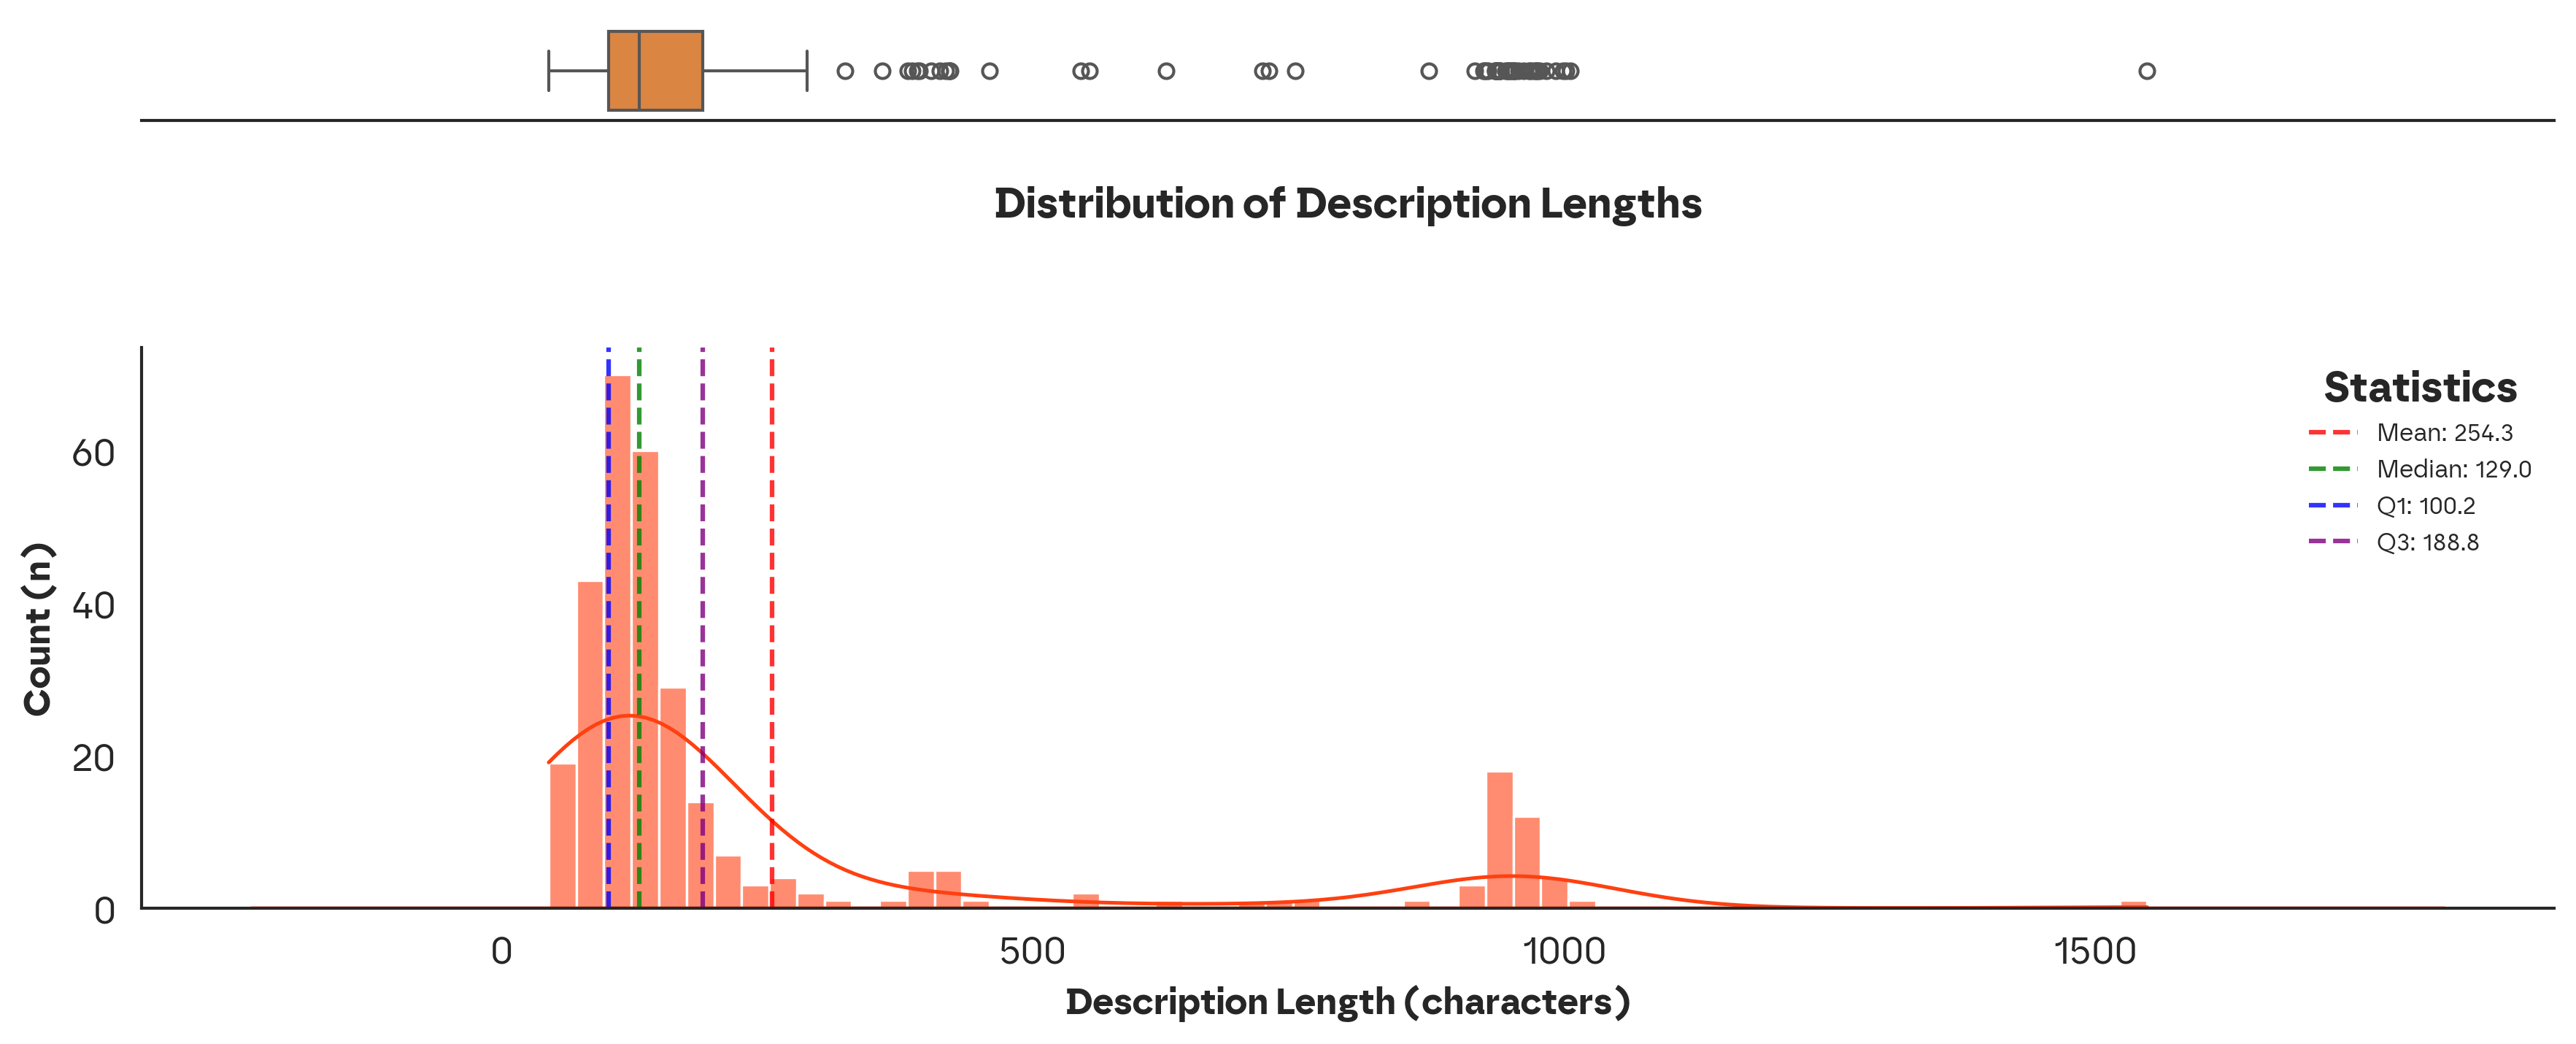

Datasets with the longest descriptions:


,title,description_length
2,Rede de monitorização e de alerta meteorológic...,1549
272,Comercialização de Hardware e Software e Serviços,1006
295,"Artes Performativas - Teatro, Dança e Música",1002
256,Ensino de Atividades Criativas e Culturais,999
260,"Edição (Livros, Jornais e Revistas)",992


In [9]:
# Analyze description length
df_lisbon['description_length'] = df_lisbon['description'].astype(str).apply(len)

# Prepare figure for Histogram & Boxplot
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(12, 5), dpi=300,
                                      sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

# Plot the Boxplot on the top
sns.boxplot(x=df_lisbon['description_length'], color=custom_palette[1], ax=ax_box)

# Plot the Histogram and the KDE on the bottom
sns.histplot(df_lisbon['description_length'], color=custom_palette[0], kde=True, stat='count', alpha=0.6, ax=ax_hist)
sns.kdeplot(df_lisbon['description_length'], color=custom_palette[0], lw=1, warn_singular=False, ax=ax_hist)

# Add mean, median and percentiles to the plot
mean_val = df_lisbon['description_length'].mean()
median_val = df_lisbon['description_length'].median()
q1_val = df_lisbon['description_length'].quantile(0.25)
q3_val = df_lisbon['description_length'].quantile(0.75)

ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Mean: {mean_val:.1f}')
ax_hist.axvline(median_val, color='green', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Median: {median_val:.1f}')
ax_hist.axvline(q1_val, color='blue', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Q1: {q1_val:.1f}')
ax_hist.axvline(q3_val, color='purple', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Q3: {q3_val:.1f}')

# Add a legend to the histogram
ax_hist.legend(loc='best', title='Statistics', title_fontproperties={'weight':'bold', 'size':'14'}, fontsize=8, frameon=False)

# Customizing the titles and labels
ax_box.set(xlabel='')
ax_hist.set_title('Distribution of Description Lengths', y=1.2, fontweight='bold', fontsize=14)
ax_hist.set_xlabel('Description Length (characters)', fontsize=12, fontweight='bold')
ax_hist.set_ylabel('Count (n)', fontsize=12, fontweight='bold')

# Remove spines
sns.despine(ax=ax_box, left=True)
sns.despine(ax=ax_hist)
plt.tight_layout()
plt.show()

# Show datasets with the longest descriptions
print("\033[1mDatasets with the longest descriptions:\033[0m")
df_lisbon.nlargest(5, 'description_length')[['title', 'description_length']]

In [10]:
# Analyze file formats
all_formats = df_lisbon['file_formats'].dropna().explode()
format_counts = all_formats.value_counts()

# DataFrame with 'n' and '%'
format_df = pd.DataFrame({
    'n': format_counts,
    '%': (format_counts / len(df_lisbon) * 100).round(2)
})
format_df

,n,%
file_formats,,
geojson,179,57.74
xlsx,43,13.87
"geojson, json-ld",16,5.16
xls,7,2.26
geojason,6,1.94
"csv, xlsx",5,1.61
shp,5,1.61
csv,5,1.61
"xls, xlsx",4,1.29


<Figure size 1200x800 with 1 Axes>
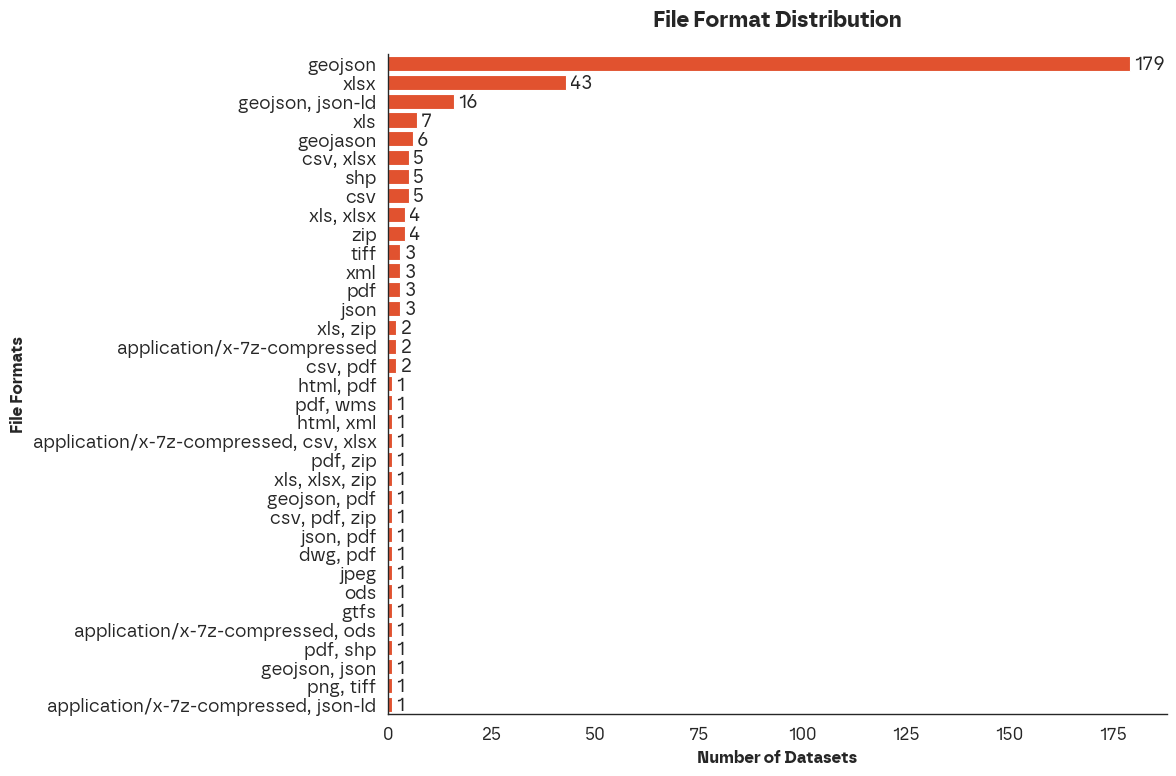

In [11]:
# Plot File Format Distribution
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=format_counts.values, y=format_counts.index, color=custom_palette[0])

# Customization
ax.set_title('File Format Distribution', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Datasets', fontsize=12, fontweight='bold')
ax.set_ylabel('File Formats', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)

# Add value labels to the bars
for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.tight_layout()
plt.show()

### **Clean Dataset**

`lisbon_datasets_clean.json` is the GeoJSON-focused snapshot used by the Lisboa Aberta runtime tools. Current snapshot size: **168 records**.

In [12]:
# Create a DataFrame for Lisbon Open Data (Clean)
df_lisbon_clean = pd.DataFrame(lisbon_datasets_clean)
print(f"\n\033[1mTotal number of cleaned datasets:\033[0m {len(df_lisbon_clean)}")

# Display the first few rows
df_lisbon_clean.head()


Total number of cleaned datasets: 168


,title,url_portal,stable_url,description,file_formats,last_updated,stable_url_comment
0,Lisboa. Pontos de encontro - Emergência.,https://dados.gov.pt/pt/datasets/plano-municip...,https://dados.gov.pt/pt/datasets/r/1df28fd3-9c...,Serviço de mapa com indicação da localização d...,geojson,2025-10-30T00:00:00,NaN
1,Zonas de Emissões Reduzidas,https://dados.gov.pt/pt/datasets/zonas-de-emis...,https://dados.gov.pt/pt/datasets/r/20eadc61-b4...,Serviço de mapa com indicação das principais e...,geojson,2025-10-30T00:00:00,NaN
2,Rede Ferroviária Subterrânea,https://dados.gov.pt/pt/datasets/https-geodado...,https://dados.gov.pt/pt/datasets/r/cc9157a3-e7...,Serviço de cartografia base. Lisbon Basemap.,geojson,2025-11-04T00:00:00,NaN
3,Rede LoRa,https://dados.gov.pt/pt/datasets/rede-lora/,https://dados.gov.pt/pt/datasets/r/4416a5ad-a5...,Serviço de mapas com a localização geográfica ...,geojson,2025-02-21T00:00:00,NaN
4,Sitios de interesse público,https://dados.gov.pt/pt/datasets/https-geodado...,https://dados.gov.pt/pt/datasets/r/6b6ed8be-c0...,"Conjunto de dados relativos a ""Sítios de inter...",geojson,2025-02-24T00:00:00,NaN


In [13]:
# Analyze file formats
all_formats = df_lisbon_clean['file_formats'].dropna().explode()
format_counts = all_formats.value_counts()

# DataFrame with 'n' and '%'
format_df = pd.DataFrame({
    'n': format_counts,
    '%': (format_counts / len(df_lisbon_clean) * 100).round(2)
})
format_df

,n,%
file_formats,,
geojson,156,92.86
"geojson, json-ld",12,7.14


In [14]:
# Output all possible 'title' values in the datasets
unique_titles = df_lisbon['title'].unique()
unique_titles

array(['Atlas Digital (Atlas Digital)Atlas Digital',
       'Plano Metropolitano de Adaptação às Alterações Climáticas (PMAAC)PMAAC',
       'Rede de monitorização e de alerta meteorológico metropolitano (Clima.AML)Clima.AML',
       'Pontos de Interesse Climate Walks', 'Percursos Climate Walks',
       'Programa 3º Encontro',
       'Lugares de estacionamento na via pública para residentes ou público em geral',
       'Áreas reguladas de estacionamento na via pública',
       'Zonas reguladas de estacionamento na via pública',
       'Túneis rodoviários geridos pela EMEL',
       'Estatísticas do número de lugares, por freguesia e por tipologia de lugar',
       'Elevadores e escadas rolantes',
       'Lisboa. Pontos de encontro - Emergência',
       'Zonas de Emissões Reduzidas', 'Rede Ferroviária Subterrânea',
       'Rede LoRa', 'Limite Unidades Territoriais - Micro',
       'Sitios de interesse público',
       'Monitorização de Parâmetros Ambientais da Cidade de Lisboa',
       '

<Figure size 4200x1200 with 1 Axes>
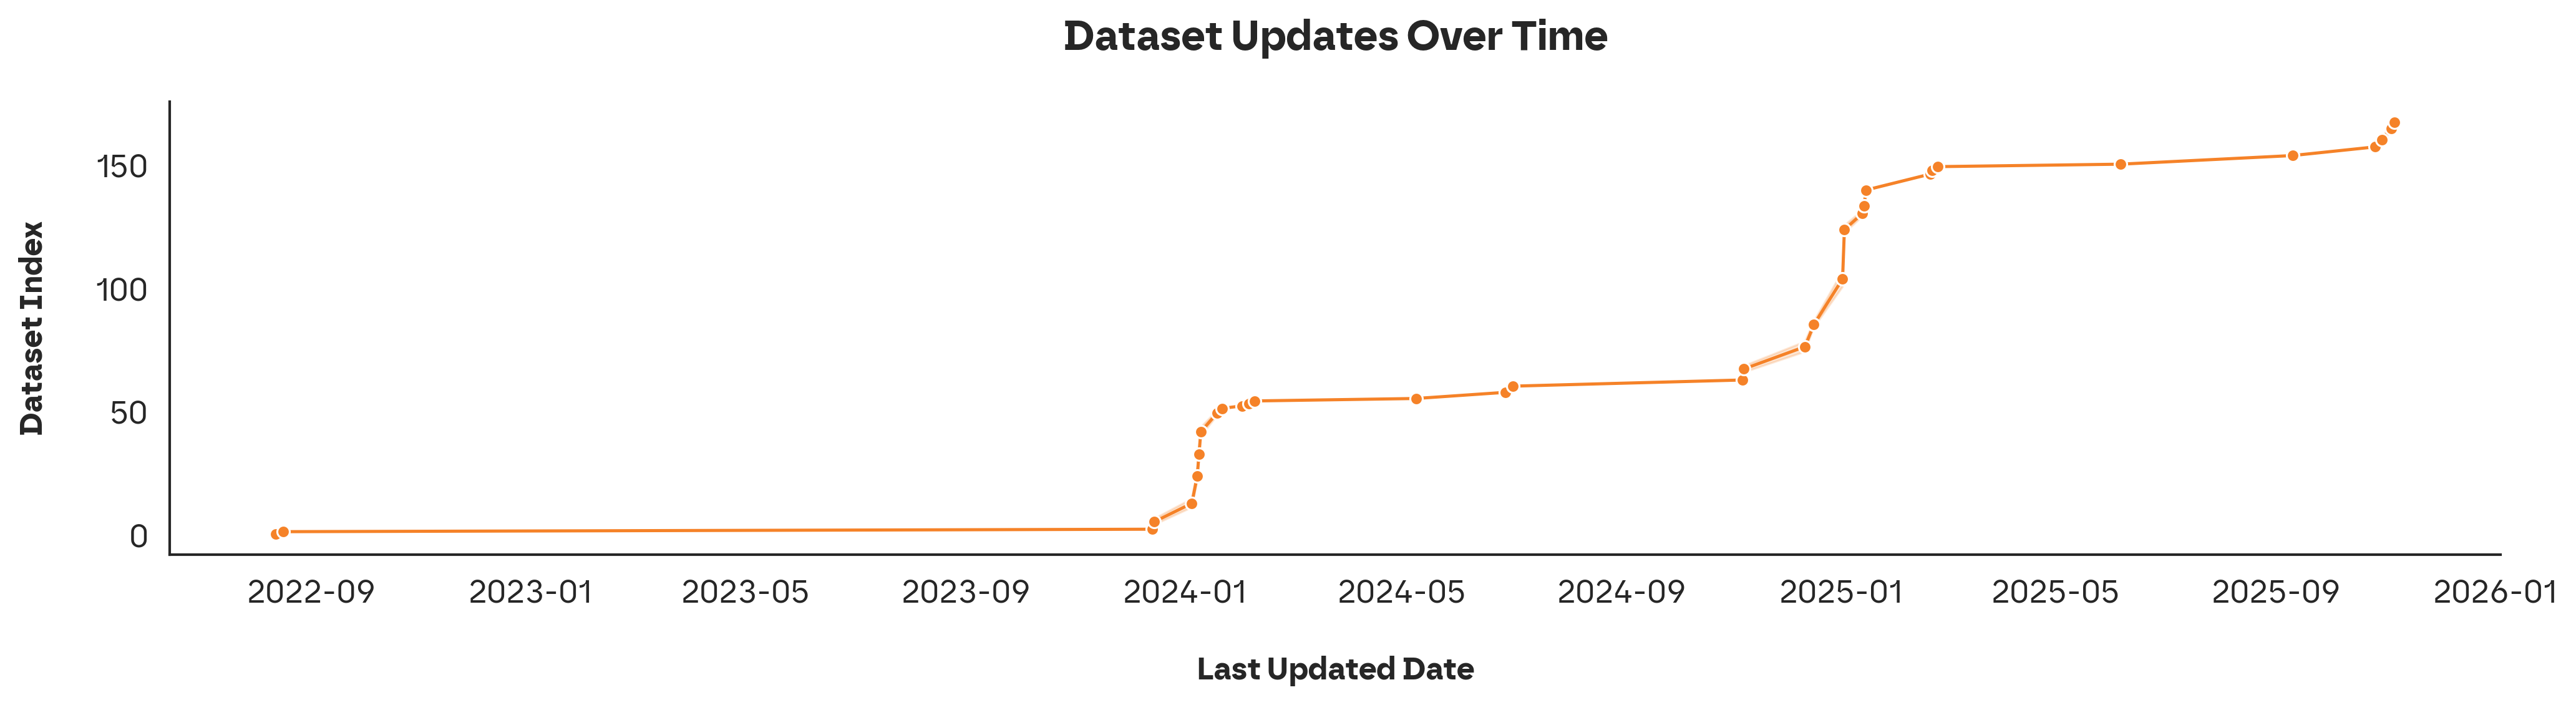

In [15]:
# Analyze last_updated dates
df_lisbon_clean['last_updated'] = pd.to_datetime(df_lisbon_clean['last_updated'], errors='coerce')

# Plot the time series of dataset updates
plt.figure(figsize=(14, 4), dpi=300)
sns.lineplot(data=df_lisbon_clean.sort_values('last_updated'), x='last_updated', y=df_lisbon_clean.index, marker='o', color=custom_palette[1])

# Customization
plt.title('Dataset Updates Over Time', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('\nLast Updated Date', fontsize=12, fontweight='bold')
plt.ylabel('Dataset Index\n', fontsize=12, fontweight='bold')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

In [16]:
# Validate that stable_url values are reachable GeoJSON or explicitly documented upstream limitations.
import json
from typing import Any, Dict, Optional

import requests

VALID_GEOJSON_TYPES = {
    "FeatureCollection", "Feature", "Point", "LineString", "Polygon",
    "MultiPoint", "MultiLineString", "MultiPolygon", "GeometryCollection",
}


def fetch_geojson(url: str, timeout: int = 15) -> Optional[Dict[str, Any]]:
    """
    Fetch and validate a GeoJSON object from a URL.

    Args:
        url: URL to fetch GeoJSON from.
        timeout: Request timeout in seconds.

    Returns:
        GeoJSON data if valid; otherwise None. The last failure reason is stored
        in ``fetch_geojson.last_error`` for reporting.
    """
    fetch_geojson.last_error = ""
    try:
        response = requests.get(
            url,
            timeout=timeout,
            headers={"User-Agent": "LISBOA-notebook-geojson-validator/2026.05"},
            allow_redirects=True,
        )
        response.raise_for_status()
        data = response.json()
        if isinstance(data, dict) and data.get("type") in VALID_GEOJSON_TYPES:
            return data
        fetch_geojson.last_error = f"Invalid GeoJSON type: {data.get('type') if isinstance(data, dict) else type(data).__name__}"
        return None
    except (requests.RequestException, json.JSONDecodeError) as exc:
        fetch_geojson.last_error = str(exc).splitlines()[0]
        return None


print("\033[1mTesting GeoJSON URLs (15s timeout)...\033[0m\n")
results = {"valid_geojson": 0, "annotated_unavailable": 0, "unexpected_failure": 0}
issue_rows = []

for idx, row in tqdm(df_lisbon_clean.iterrows(), total=len(df_lisbon_clean), desc="Checking GeoJSON URLs"):
    url = row["stable_url"]
    title = row["title"]
    comment = str(row.get("stable_url_comment", "") or "").strip()
    geojson_data = fetch_geojson(url)

    if geojson_data:
        results["valid_geojson"] += 1
        continue

    status = "annotated_upstream_unavailable" if comment else "unexpected_failure"
    if comment:
        results["annotated_unavailable"] += 1
    else:
        results["unexpected_failure"] += 1

    issue_rows.append(
        {
            "index": int(idx) + 1,
            "title": title,
            "status": status,
            "reason": comment or fetch_geojson.last_error,
            "url": url,
        }
    )

print("\n" + "=" * 72)
print("\033[1mSummary:\033[0m")
print(f"  \033[1;32m✅ Valid GeoJSON:\033[0m {results['valid_geojson']}")
print(f"  \033[1;33m⚠️ Annotated upstream unavailable:\033[0m {results['annotated_unavailable']}")
print(f"  \033[1;32m✅ Unexpected failures:\033[0m {results['unexpected_failure']}")
print(f"  \033[1m  Total:\033[0m {len(df_lisbon_clean)}")
print("=" * 72)

if issue_rows:
    print("\n\033[1mDocumented non-working resources requiring upstream replacement:\033[0m")
    display(pd.DataFrame(issue_rows))

if results["unexpected_failure"] == 0:
    print("\n\033[1;32m✅ No unexpected GeoJSON failures detected.\033[0m")
else:
    print("\n\033[1;33m⚠️ Unexpected failures require follow-up before treating this snapshot as clean.\033[0m")


Testing GeoJSON URLs (15s timeout)...




Checking GeoJSON URLs:   0%|          | 0/168 [00:00<?, ?it/s]


Checking GeoJSON URLs:   1%|          | 1/168 [00:00<01:18,  2.12it/s]


Checking GeoJSON URLs:   1%|          | 2/168 [00:00<01:17,  2.16it/s]


Checking GeoJSON URLs:   2%|▏         | 3/168 [00:01<01:14,  2.23it/s]

...


Checking GeoJSON URLs: 100%|██████████| 168/168 [01:32<00:00,  2.36it/s]


Checking GeoJSON URLs: 100%|██████████| 168/168 [01:32<00:00,  1.82it/s]


Summary:
  ✅ Valid GeoJSON: 161
  ⚠️ Annotated upstream unavailable: 7
  ✅ Unexpected failures: 0
    Total: 168

Documented non-working resources requiring upstream replacement:


,index,title,status,reason,url
0,59,Outras Instituições de I&D e Fundações,annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/3e622352-83...
1,72,Laboratórios Associados,annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/70ed7307-0f...
2,79,Infraestruturas e Parques de Ciência e Tecnologia,annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/3919b6a7-a0...
3,96,"Faculdades, Escolas e Institutos",annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/8912dbcd-b9...
4,102,Espaços e Ambientes Criativos,annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/3732525c-41...
5,140,Centros de Investigação e de Estudos,annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/c524fdf8-22...
6,165,Apoio e Financiamento à Inovação,annotated_upstream_unavailable,Not updated on 2026-05-18: official dados.cm-l...,https://dados.gov.pt/pt/datasets/r/de6d1d37-b6...



✅ No unexpected GeoJSON failures detected.


In [17]:
# Example: Agent tool for dynamic GeoJSON fetching
#          This simulates what the agent will do when it needs geospatial data

def agent_fetch_geojson(title_keyword: str, timeout: int = 15):
    """
    Simulates how the agent will fetch GeoJSON data dynamically.

    Args:
        title_keyword (str): Keyword to search in dataset titles.
        timeout (int): Request timeout in seconds.

    Returns:
        dict: GeoJSON data or error information.
    """
    import time

    # Search for dataset
    matches = df_lisbon_clean[
        df_lisbon_clean['title'].str.contains(title_keyword, case=False, na=False)
    ]

    if matches.empty:
        return {"error": f"No dataset found for: {title_keyword}"}

    dataset = matches.iloc[0]
    url = dataset['stable_url']
    title = dataset['title']

    print(f"\033[1m🔍 Searching for:\033[0m {title_keyword}")
    print(f"\033[1m✅ Found:\033[0m {title}")
    print(f"\033[1m🌐 URL:\033[0m {url}")
    print(f"\033[1m⏱️ Fetching with {timeout}s timeout...\033[0m\n")

    start_time = time.time()

    # Fetch GeoJSON
    geojson = fetch_geojson(url, timeout=timeout)

    elapsed = time.time() - start_time

    if geojson:
        feature_count = len(geojson.get('features', []))
        print("\033[1;32m✅ Success!\033[0m")
        print(f"  ⏱️ Time: {elapsed:.2f}s")
        print(f"  📊 Features: {feature_count}")
        print(f"  📦 Type: {geojson.get('type')}")
        return geojson
    else:
        print(f"\033[1;31m❌ Failed after {elapsed:.2f}s\033[0m")
        return {"error": "Failed to fetch or invalid GeoJSON"}

# Test 1: Fetch Metro stations
print("="*70)
print("\033[1mTest 1: Metro Stations\033[0m")
print("="*70)
metro_data = agent_fetch_geojson("metro")

if metro_data and 'features' in metro_data:
    print("\n\033[1mFirst station:\033[0m")
    first_station = metro_data['features'][0]
    print(f"  Name: {first_station['properties'].get('NOME', 'N/A')}")
    print(f"  Line: {first_station['properties'].get('LINHA', 'N/A')}")
    print(f"  Coordinates: {first_station['geometry']['coordinates']}")

print("\n" + "="*70 + "\n")

Test 1: Metro Stations
🔍 Searching for: metro
✅ Found: Estações de Metro
🌐 URL: https://services.arcgis.com/1dSrzEWVQn5kHHyK/arcgis/rest/services/POITransportes/FeatureServer/1/query?outFields=*&where=1%3D1&f=geojson
⏱️ Fetching with 15s timeout...



✅ Success!
  ⏱️ Time: 0.24s
  📊 Features: 50
  📦 Type: FeatureCollection

First station:
  Name: Cais do Sodré
  Line: Verde
  Coordinates: [-9.14620795021712, 38.7061150810876]




## <span style="color: #ffffff;">Visit Lisbon Analysis</span>
<style>
@import url('https://fonts.cdnfonts.com/css/avenir-next-lt-pro?styles=29974');
</style>

<div style="background: transparent;
            padding: 10px; color: white; border-radius: 300px; text-align: center;
            border: 2px solid #FFCD41;">
    <center><h2 style="margin-left: 120px;margin-top: 10px; margin-bottom: 4px; color: #FFCD41;
                       font-size: 24px; font-family: 'Avenir Next LT Pro', sans-serif;"><b> Visit Lisbon Analysis</b></h2></center>
</div>

<br>

This section analyzes the local event and place snapshots scraped from the **[Visit Lisboa](https://www.visitlisboa.com/)** official tourism website. Counts are snapshot-dependent and should be refreshed after the scraping workflows run.

Current local snapshot:

- `events.json`: **181 event records**
- `places.json`: **1,170 place records**

### **🔎 Dataset Attributes**

<center><b>Table 2 | </b> Dataset Attributes with Descriptions (Visit Lisboa snapshots). <br>

<br>

|       | **Field**                          | **Events** | **Places** | **Description**                                       | **Type** |
|:-----:|:----------------------------------:|:----------:|:----------:|:------------------------------------------------------|:--------:|
| **1** | `url`                              | ✅ | ✅ | Source URL of the event or place                       | **`Text`** |
| **2** | `title`                            | ✅ | ✅ | Event or place title                                   | **`Text`** |
| **3** | `category`                         | ✅ | ✅ | Category classification                                | **`Categorical`** |
| **4** | `short_description`                | ✅ | ✅ | Short textual summary                                  | **`Text`** |
| **5** | `full_description`                 | ✅ | ✅ | Detailed scraped description                           | **`Text`** |
| **6** | `image_urls`                       | ✅ | ✅ | Image URLs associated with the record                  | **`List`** |
| **7** | `video_urls`                       | ✅ | ✅ | Video URLs associated with the record                  | **`List`** |
| **8** | `location`                         | ✅ | ✅ | Human-readable location/address text                   | **`Text`** |
| **9** | `information_links`                | ✅ | ✅ | Additional links extracted from the page               | **`Object`** |
| **10**| `dates`                            | ✅ | ❌ | Structured event dates                                 | **`List`** |
| **11**| `venue_name`                       | ✅ | ❌ | Event venue name when parsed                           | **`Text`** |
| **12**| `venue_locations`                  | ✅ | ❌ | Parsed event venue-location variants                   | **`List`** |
| **13**| `price`                            | ✅ | ❌ | Event price/free-entry text                            | **`Text`** |
| **14**| `schedule_notes`                   | ✅ | ❌ | Event schedule notes                                   | **`Text/List`** |
| **15**| `buy_tickets_url`                  | ✅ | ❌ | Ticketing URL when available                           | **`Text/Null`** |
| **16**| `highlight_links`                  | ✅ | ❌ | Highlighted event links                                | **`Object/List`** |
| **17**| `features`                         | ❌ | ✅ | Place features and tags                                | **`List`** |
| **18**| `contact_info`                     | ❌ | ✅ | Phone, website and other contact fields                | **`Object`** |
| **19**| `social_media`                     | ❌ | ✅ | Social media links                                     | **`Object`** |
| **20**| `schedules`                        | ❌ | ✅ | Place opening schedule entries                         | **`List`** |
| **21**| `additional_sections`              | ❌ | ✅ | Extra page sections extracted from the place page       | **`List`** |
| **22**| `tickets_offers`                   | ❌ | ✅ | Ticket/offer metadata when present                     | **`Object/Null`** |
| **23**| `tripadvisor`                      | ❌ | ✅ | TripAdvisor metadata when present                      | **`Object`** |
| **24**| `lisboa_card_benefit`              | ❌ | ✅ | Lisboa Card benefit text when present                  | **`Text/Null`** |
| **25**| `lisboa_card_discount`             | ❌ | ✅ | Lisboa Card discount value/text when present           | **`Text/Null`** |
| **26**| `lisbon_tourism_member`            | ❌ | ✅ | Whether the place is marked as a Lisbon tourism member | **`Boolean`** |

</center>

In [18]:
# Convert 'visitlisbon_events' and 'visitlisbon_places' JSON data to DataFrames
events_df = pd.DataFrame(events_data)
places_df = pd.DataFrame(places_data)

In [19]:
# Count the number of observations in each file
num_events = len(events_df)
num_places = len(places_df)

print(f"\033[1mNumber of observations in events.json:\033[0m {num_events}")
print(f"\033[1mNumber of observations in places.json:\033[0m {num_places}")

Number of observations in events.json: 181
Number of observations in places.json: 1170


In [20]:
# Frequency table for events.json categories
events_freq = events_df['category'].value_counts().reset_index()
events_freq.columns = ['Category', 'n']
events_freq['%'] = (events_freq['n'] / events_freq['n'].sum() * 100).round(2)

print("\033[1mFrequency table for events.json:\033[0m")
events_freq.set_index('Category')

Frequency table for events.json:


,n,%
Category,,
Music,45,25.00
Exhibitions,43,23.89
Main Events,25,13.89
Fairs,21,11.67
Festivals,16,8.89
Others,14,7.78
Theater Opera & Dance,6,3.33
Sports,6,3.33
Cinema,4,2.22


In [21]:
# Frequency table for places.json categories
places_freq = places_df['category'].value_counts().reset_index()
places_freq.columns = ['Category', 'n']
places_freq['%'] = (places_freq['n'] / places_freq['n'].sum() * 100).round(2)

print("\033[1mFrequency table for places.json:\033[0m")
places_freq.set_index('Category')

Frequency table for places.json:


,n,%
Category,,
Hotel,230,23.02
Restaurant,121,12.11
Tours,105,10.51
Museums,69,6.91
Monuments,60,6.01
Museums & Monuments,48,4.80
DMCS & PCOS,32,3.20
Apartments & Hotel Apartments,32,3.20
Shopping,31,3.10


In [22]:
# Combined frequency table
events_freq['Source'] = 'Events'
places_freq['Source'] = 'Places'
combined_freq = pd.concat([events_freq, places_freq])
combined_freq = combined_freq.groupby('Category')['n'].sum().reset_index()
combined_freq['%'] = (combined_freq['n'] / combined_freq['n'].sum() * 100).round(2)
combined_freq = combined_freq.sort_values('n', ascending=False)

<Figure size 1400x800 with 1 Axes>
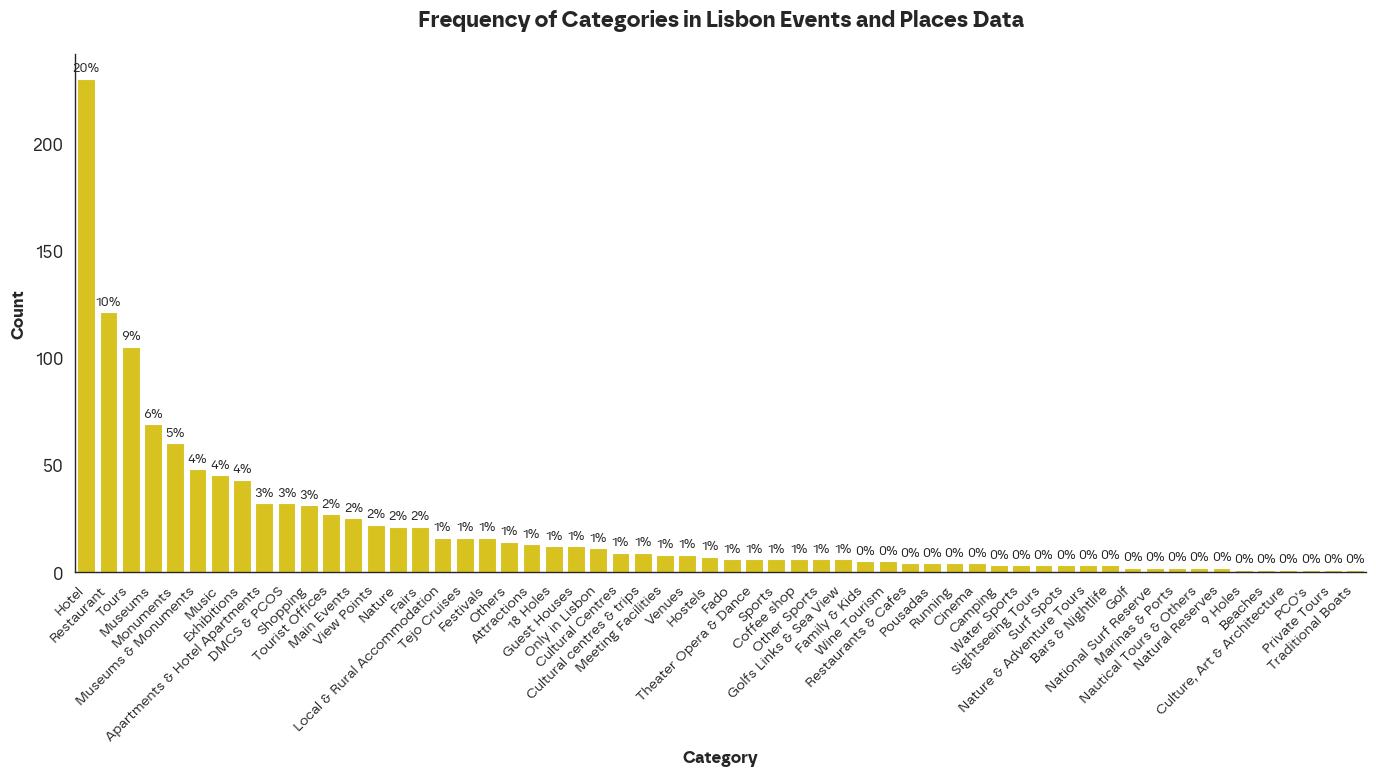

In [23]:
# Create a bar chart in yellow tones for Lisbon categories
plt.figure(figsize=(14, 8))

# Create barplot
ax = sns.barplot(data=combined_freq, x='Category', y='n', color=custom_palette[2])

# Customization
ax.set_title('Frequency of Categories in Lisbon Events and Places Data', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add % labels
for i in ax.containers:
    ax.bar_label(i, labels=[f'{p:.0f}%' for p in combined_freq['%']], padding=3, fontsize=10)

# Remove spines
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()